# TTS Analysis

In addition to human review and evaluation, let's gather metrics to analyze performance of the three TTS models under consideration. Qwen3-TTS was chosen because of its quality, Piper was chosen because of its speed, and Facebook was chosen because of its popularity. Which model offers a comfortable trade-off between speed and accuracy?

Latency consists in the time each model takes to create a wav file output for the same input text, shown below. This measure will be very important to provide quick TTS services back to the user with long LLM responses. Accuracy metrics are gathered by judging the jiwer calculations we used for the ASR model evaluation. Except here, we are using the same model on audio produced by each TTS model. It is an approximate evaluation because there is some scope of error based on the performance of an ASR model. However, that we're using the same ASR model on each TTS output should give us a relative set of metrics to judge TTS quality

In [1]:
# TTS models were run over the following text

print("\nTTS input text:\n")
print((open('test_assets/sample_text.txt').read()))


TTS input text:

Smoking appears to lower the risk of developing Parkinson's disease (PD), a neurodegenerative disorder, compared to non-smokers. However, recent studies have shown that nicotine, a key component of cigarette smoke, does not improve motor function in PD patients when administered as a therapeutic treatment.


In [2]:
# import metrics

import pandas as pd
import json

tts_latency = json.loads(open('test_output/tts_latency.json').read())
tts_latency

{'facebook': 4.138095140457153,
 'piper': 0.6816840171813965,
 'qwen': 31.191812753677368,
 'kokoro': 6.102501153945923}

In [3]:
tts_asr_metrics = json.loads(open(f'test_output/tts_asr_metrics.json').read())
tts_asr_metrics

{'facebook': {'model': 'facebook/mms-tts-eng',
  'wer': 0.22727272727272727,
  'cer': 0.0749185667752443,
  'mer': 0.22727272727272727,
  'wil': 0.3744588744588745,
  'wip': 0.6255411255411255},
 'piper': {'model': 'piper-config-en_US-kathleen-low',
  'wer': 0.045454545454545456,
  'cer': 0.009771986970684038,
  'mer': 0.045454545454545456,
  'wil': 0.08884297520661144,
  'wip': 0.9111570247933886},
 'qwen': {'model': 'qwen3-tts-12hz-0.6b-base',
  'wer': 0.06818181818181818,
  'cer': 0.013029315960912053,
  'mer': 0.06818181818181818,
  'wil': 0.13171487603305798,
  'wip': 0.868285123966942},
 'kokoro': {'model': 'hexgrad/Kokoro-82M',
  'wer': 0.09090909090909091,
  'cer': 0.016286644951140065,
  'mer': 0.09090909090909091,
  'wil': 0.17355371900826455,
  'wip': 0.8264462809917354}}

In [5]:
# create table of duration

time_df = pd.DataFrame([tts_latency.keys(), tts_latency.values()]).T
time_df.rename(columns={0:'model',1:'latency'}, inplace=True)
time_df = time_df.set_index('model').sort_values('latency')
time_df.head()

,latency
model,
piper,0.681684
facebook,4.138095
kokoro,6.102501
qwen,31.191813


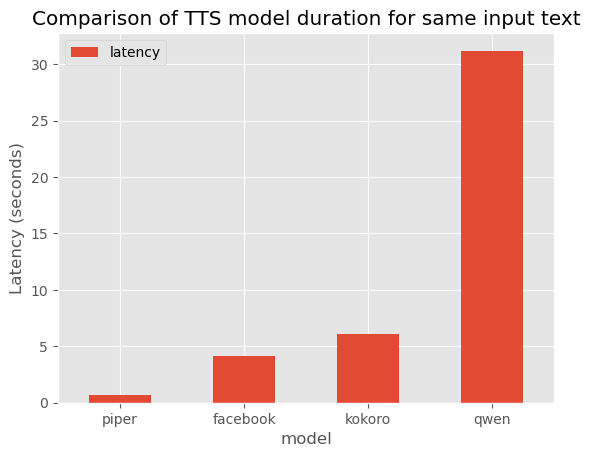

In [6]:
# plot latency

import matplotlib.pyplot as plt

plt.style.use('ggplot') 

ax = time_df.plot(kind="bar", rot=0, ylabel = 'Latency (seconds)')
_ = ax.set_title('Comparison of TTS model duration for same input text')

In [7]:
# create table of ASR metrics over three different TTS model outputs, then plot

asr_df = pd.DataFrame(tts_asr_metrics.values())
asr_df.set_index('model').head()

,wer,cer,mer,wil,wip
model,,,,,
facebook/mms-tts-eng,0.227273,0.074919,0.227273,0.374459,0.625541
piper-config-en_US-kathleen-low,0.045455,0.009772,0.045455,0.088843,0.911157
qwen3-tts-12hz-0.6b-base,0.068182,0.013029,0.068182,0.131715,0.868285
hexgrad/Kokoro-82M,0.090909,0.016287,0.090909,0.173554,0.826446


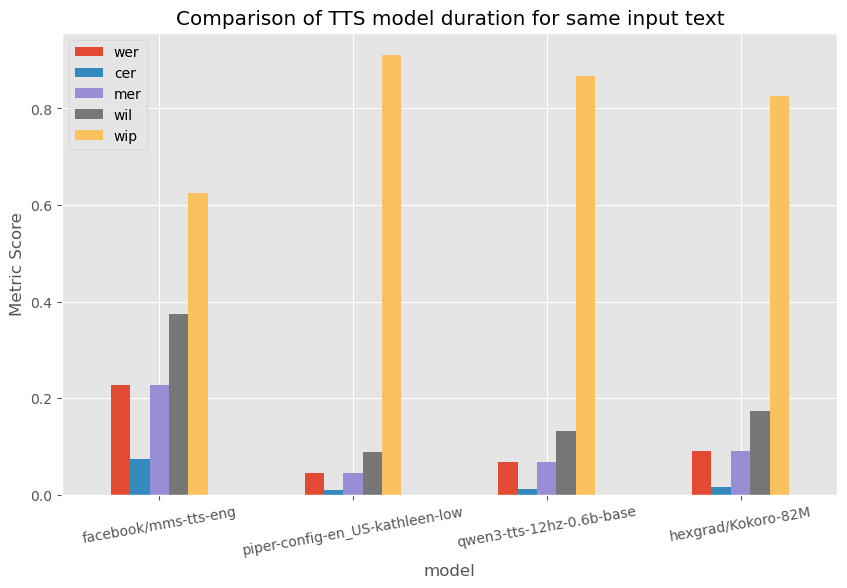

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.style.use('ggplot') 

ax = asr_df.plot(kind="bar", rot=10, figsize=(10, 6), x='model', ylabel = 'Metric Score')

_ = ax.set_title('Comparison of TTS model duration for same input text')


# Discussion

We see that clearly the Qwen-TTS model has the best quality metrics but it comes at too steep a latency cost. If it takes 30+ seconds to output relatively small input using my MacOS mps accelerator, then users will not wait for an anwer. In fact, the latency in the response could give the impression that the application is unresponsive. When we look at the Piper model output, we see that the metrics are quite similar to Qwen without the latency. The speed of the output is less than 3/4 of a second. This speed in performance certainly makes Piper the candidate TTS we will choose for the application. Though the Facebook is very similar, when we listen to the quality of the voice, the initial 'S' sound of 'Smoking' in the text is missing, and the voice feels rather contrived. Overall, the Piper model offers a fast response that does not seem to come at the cost of quality.

After the decision to use the Piper model, I decided to integrate another test with the Kokoro model because it sounded much more natural. Even though it was slower, human evaluators felt it was well worth the wait over the Piper model. They found with the Piper model, the lack of quality was a distraction away from understanding the content itself. Essentially the quality got in the way, whereas with the Kokoro model, the voice was much easier to listen to. Therefore, the Kokoro model was chosen.

This is a great example of how human evaluation sometimes disagrees with automated evaluations. Taking a look at the metrics chart above, the Piper model wins overall. But in this case, the humans were right -- the Kokoro model gives a much more natural sounding response. And if the quality of the response is getting in the way of comprehending the voice (like with the Piper model), then something needs to change. In this case, the evaluators judged hands-down that the Kokoro model delivers on quality with an acceptable wait time.